## 1. Setup
Install dependencies and import everything needed for this notebook.

In [ ]:
# Install once per Colab session — takes ~60 seconds
!pip install "numpy<2.0" --quiet
!pip install ultralytics==8.3.0 --quiet
!pip install scipy --quiet

print('Installation complete.')

Installation complete.


In [ ]:
import os
import zipfile
import csv
import time
import logging
from pathlib import Path

import cv2
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO

# suppress ultralytics verbose output
logging.getLogger('ultralytics').setLevel(logging.WARNING)

print('Imports OK.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Imports OK.


## 2. Mount Drive + Upload Dataset

Mount Google Drive so outputs persist after the session ends.
Then upload `mall_dataset.zip` once — it stays in Drive for all future sessions.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# All outputs saved here — survives session resets
DRIVE_DIR = Path('/content/drive/MyDrive/shoplens')
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

print(f'Drive mounted. Output folder: {DRIVE_DIR}')

Mounted at /content/drive
Drive mounted. Output folder: /content/drive/MyDrive/shoplens


In [ ]:
DATASET_DIR = Path('/content/mall_dataset')
FRAMES_DIR = DATASET_DIR / 'frames'
GT_PATH = DATASET_DIR / 'mall_gt.mat'

# Extract from your existing zip in Drive
DRIVE_ZIP = Path('/content/drive/MyDrive/datasets/mall_dataset.zip')

if FRAMES_DIR.exists() and len(list(FRAMES_DIR.glob('*.jpg'))) == 2000:
    print('Dataset already extracted. Skipping.')
else:
    print('Extracting from Drive...')
    with zipfile.ZipFile(DRIVE_ZIP, 'r') as z:
        z.extractall('/content/')
    print('Done.')

frame_count = len(list(FRAMES_DIR.glob('*.jpg')))
assert frame_count == 2000, f'Expected 2000 frames, got {frame_count}'
assert GT_PATH.exists(), f'mall_gt.mat not found'
print(f'Dataset ready: {frame_count} frames.')

Extracting from Drive...
Done.
Dataset ready: 2000 frames.


## 3. Load Ground Truth

`mall_gt.mat` contains:
- `count`: (2000,) array — number of people per frame (ground truth)
- `frame`: (2000,) array of structs — (x, y) head positions per person per frame

We use `count` as the reference for accuracy measurement.

In [ ]:
def load_ground_truth(mat_path: Path):
    """
    Load Mall Dataset ground truth.

    Returns:
        gt_counts: (2000,) int array — person count per frame
        gt_locations: (2000,) object array — each entry is (N, 2) float array of head (x, y) positions
    """
    mat = scipy.io.loadmat(mat_path)

    gt_counts = mat['count'].flatten().astype(int)

    frames_raw = mat['frame'].flatten()
    gt_locations = np.empty(len(frames_raw), dtype=object)
    for i, entry in enumerate(frames_raw):
        # Navigate nested MATLAB struct: entry[0][0][0] gives (N, 2) location array
        gt_locations[i] = entry[0][0][0]

    return gt_counts, gt_locations


gt_counts, gt_locations = load_ground_truth(GT_PATH)

print(f'Ground truth loaded: {len(gt_counts)} frames')
print(f'Person count range: {gt_counts.min()} to {gt_counts.max()} (mean: {gt_counts.mean():.1f})')
print(f'Frame 1 — GT count: {gt_counts[0]}, head positions shape: {gt_locations[0].shape}')

Ground truth loaded: 2000 frames
Person count range: 13 to 53 (mean: 31.2)
Frame 1 — GT count: 29, head positions shape: (29, 2)


## 4. Explore Dataset

Look at 6 sample frames with ground truth head positions overlaid.
Understand what the camera sees before running detection.

In [ ]:
def frame_path(frame_idx: int) -> Path:
    """Return path to frame image. Frame indices are 1-based."""
    return FRAMES_DIR / f'seq_{frame_idx:06d}.jpg'


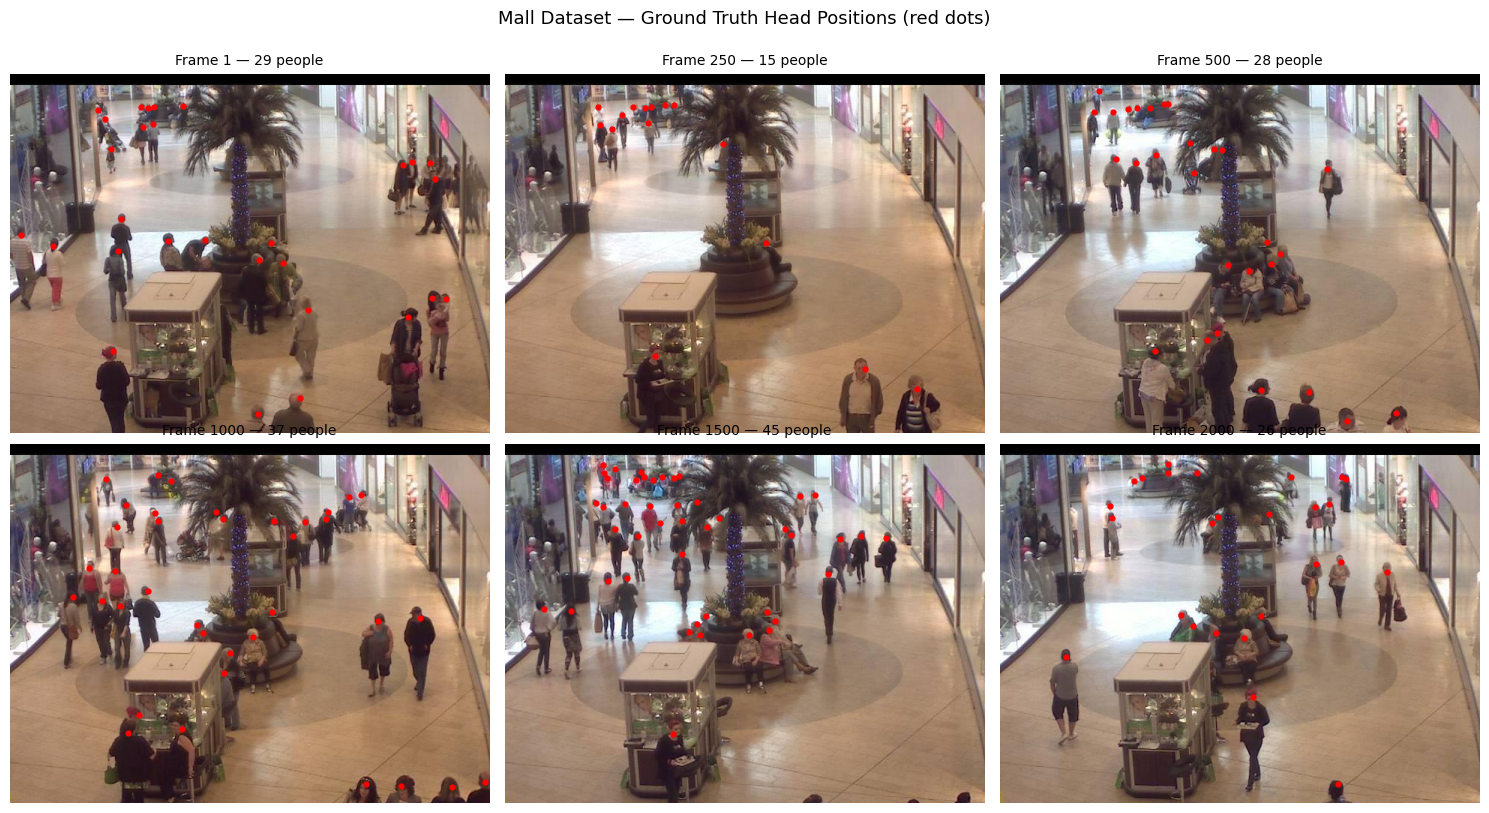

Saved: gt_visualization.png


In [ ]:
def visualize_ground_truth(frame_indices, gt_counts, gt_locations):
    """Show frames with GT head positions as red dots."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for ax, idx in zip(axes, frame_indices):
        img = cv2.imread(str(frame_path(idx)))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)

        locs = gt_locations[idx - 1]
        ax.scatter(locs[:, 0], locs[:, 1], c='red', s=12, zorder=5, label='GT head')

        ax.set_title(f'Frame {idx} — {gt_counts[idx - 1]} people', fontsize=10)
        ax.axis('off')

    plt.suptitle('Mall Dataset — Ground Truth Head Positions (red dots)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(DRIVE_DIR / 'gt_visualization.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Saved: gt_visualization.png')


visualize_ground_truth([1, 250, 500, 1000, 1500, 2000], gt_counts, gt_locations)

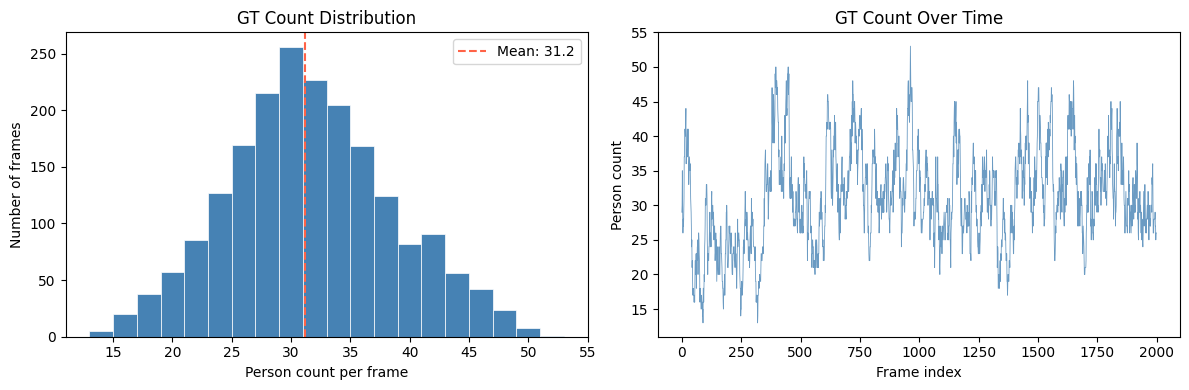

Saved: gt_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(gt_counts, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(gt_counts.mean(), color='tomato', linestyle='--', label=f'Mean: {gt_counts.mean():.1f}')
axes[0].set_xlabel('Person count per frame')
axes[0].set_ylabel('Number of frames')
axes[0].set_title('GT Count Distribution')
axes[0].legend()

axes[1].plot(gt_counts, color='steelblue', linewidth=0.6, alpha=0.8)
axes[1].set_xlabel('Frame index')
axes[1].set_ylabel('Person count')
axes[1].set_title('GT Count Over Time')

plt.tight_layout()
plt.savefig(DRIVE_DIR / 'gt_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: gt_distribution.png')

## 5. Detection on Single Frame (Smoke Test)

Load YOLOv8n. Run on one frame. Verify it works before running on 2000 frames.

In [ ]:
# YOLOv8n — smallest and fastest variant. Runs on CPU.
# Downloads pretrained weights (~6MB) on first run, cached afterward.
model = YOLO('yolov8n.pt')
print('YOLOv8n loaded.')

100%|██████████| 6.25M/6.25M [00:00<00:00, 72.7MB/s]


YOLOv8n loaded.


In [ ]:
def detect_persons(model, img_path: Path, conf: float = 0.3):
    """
    Run YOLOv8 on a single frame.

    Returns:
        count: number of persons detected
        boxes: (N, 4) array of [x1, y1, x2, y2] bounding boxes
    """
    results = model(
        str(img_path),
        classes=[0],   # 0 = person in COCO
        conf=conf,
        verbose=False,
        device='cpu',
    )
    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return 0, np.empty((0, 4))
    xyxy = boxes.xyxy.cpu().numpy()
    return len(xyxy), xyxy


test_idx = 1
detected, boxes = detect_persons(model, frame_path(test_idx), conf=0.3)
gt = gt_counts[test_idx - 1]
print(f'Frame {test_idx}: detected={detected}, GT={gt}, error={abs(detected - gt)}')

Frame 1: detected=18, GT=29, error=11


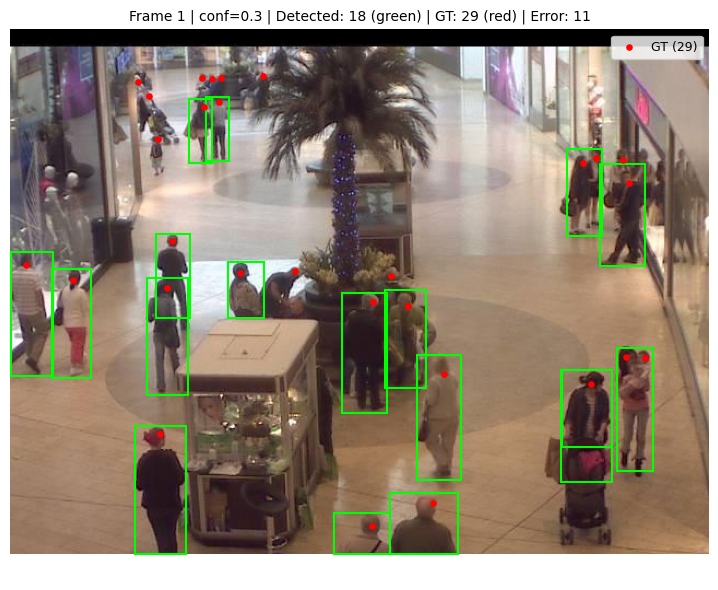

In [ ]:
def visualize_detection(frame_idx, boxes, gt_count, detected_count, conf):
    """Overlay YOLO bounding boxes and GT head dots on a frame."""
    img = cv2.imread(str(frame_path(frame_idx)))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(img_rgb)

    for x1, y1, x2, y2 in boxes:
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=1.5, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)

    locs = gt_locations[frame_idx - 1]
    ax.scatter(locs[:, 0], locs[:, 1], c='red', s=14, zorder=5, label=f'GT ({gt_count})')

    ax.set_title(
        f'Frame {frame_idx} | conf={conf} | Detected: {detected_count} (green) | GT: {gt_count} (red) | Error: {abs(detected_count - gt_count)}',
        fontsize=10
    )
    ax.legend(loc='upper right', fontsize=9)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(DRIVE_DIR / f'detection_frame{frame_idx}.png', dpi=100, bbox_inches='tight')
    plt.show()


visualize_detection(test_idx, boxes, gt_counts[test_idx - 1], detected, conf=0.3)

## 6. Detection on 50 Frames

Run on 50 evenly spaced frames. Compute MAE and RMSE against GT.
This is a fast check before the full 2000-frame run.

In [ ]:
def compute_metrics(results: list) -> dict:
    """Compute MAE, RMSE, max error and exact match count."""
    errors = np.array([r['error'] for r in results])
    return {
        'mae': float(errors.mean()),
        'rmse': float(np.sqrt((errors ** 2).mean())),
        'max_error': int(errors.max()),
        'frames_exact': int((errors == 0).sum()),
    }


def run_detection_batch(model, frame_indices: list, gt_counts, conf: float) -> list:
    """Run detection on a list of frames. Returns list of result dicts."""
    results = []
    total = len(frame_indices)

    for i, idx in enumerate(frame_indices):
        detected, _ = detect_persons(model, frame_path(idx), conf=conf)
        gt = gt_counts[idx - 1]
        error = abs(detected - int(gt))
        results.append({'frame_id': idx, 'gt_count': int(gt), 'detected_count': detected, 'error': error})

        if (i + 1) % 10 == 0 or (i + 1) == total:
            print(f'  [{i + 1:4d}/{total}] frame {idx:4d} — detected={detected:3d}, GT={int(gt):3d}, error={error}')

    return results


sample_50 = list(range(1, 2001, 40))[:50]
QUICK_CONF = 0.3

print(f'Running on {len(sample_50)} frames (conf={QUICK_CONF})...')
results_50 = run_detection_batch(model, sample_50, gt_counts, conf=QUICK_CONF)

m50 = compute_metrics(results_50)
print(f'\nResults (50 frames, conf={QUICK_CONF}):')
print(f'  MAE:  {m50["mae"]:.2f}')
print(f'  RMSE: {m50["rmse"]:.2f}')
print(f'  Max error: {m50["max_error"]}')
print(f'  Exact: {m50["frames_exact"]}/50')

Running on 50 frames (conf=0.3)...
  [  10/50] frame  361 — detected= 18, GT= 35, error=17
  [  20/50] frame  761 — detected= 24, GT= 39, error=15
  [  30/50] frame 1161 — detected= 19, GT= 36, error=17
  [  40/50] frame 1561 — detected= 25, GT= 46, error=21
  [  50/50] frame 1961 — detected= 15, GT= 29, error=14

Results (50 frames, conf=0.3):
  MAE:  14.40
  RMSE: 14.97
  Max error: 27
  Exact: 0/50


## 7. Threshold Tuning

- **Too low** → false positives (detects bags, shadows as people)
- **Too high** → misses real people

We test 7 thresholds on the 50-frame sample and pick the one with lowest MAE.

In [ ]:
THRESHOLDS = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
threshold_results = []

for conf in THRESHOLDS:
    results = run_detection_batch(model, sample_50, gt_counts, conf=conf)
    m = compute_metrics(results)
    threshold_results.append({'conf': conf, **m})
    print(f'conf={conf:.2f} -> MAE={m["mae"]:.2f}, RMSE={m["rmse"]:.2f}, exact={m["frames_exact"]}/50')

best = min(threshold_results, key=lambda x: x['mae'])
BEST_CONF = best['conf']
print(f'\nBest threshold: {BEST_CONF} (MAE={best["mae"]:.2f})')

  [  10/50] frame  361 — detected= 27, GT= 35, error=8
  [  20/50] frame  761 — detected= 40, GT= 39, error=1
  [  30/50] frame 1161 — detected= 25, GT= 36, error=11
  [  40/50] frame 1561 — detected= 33, GT= 46, error=13
  [  50/50] frame 1961 — detected= 20, GT= 29, error=9
conf=0.10 -> MAE=5.88, RMSE=6.75, exact=2/50
  [  10/50] frame  361 — detected= 24, GT= 35, error=11
  [  20/50] frame  761 — detected= 32, GT= 39, error=7
  [  30/50] frame 1161 — detected= 22, GT= 36, error=14
  [  40/50] frame 1561 — detected= 26, GT= 46, error=20
  [  50/50] frame 1961 — detected= 18, GT= 29, error=11
conf=0.15 -> MAE=9.36, RMSE=10.36, exact=1/50
  [  10/50] frame  361 — detected= 21, GT= 35, error=14
  [  20/50] frame  761 — detected= 28, GT= 39, error=11
  [  30/50] frame 1161 — detected= 22, GT= 36, error=14
  [  40/50] frame 1561 — detected= 26, GT= 46, error=20
  [  50/50] frame 1961 — detected= 18, GT= 29, error=11
conf=0.20 -> MAE=12.10, RMSE=12.87, exact=0/50
  [  10/50] frame  361 — d

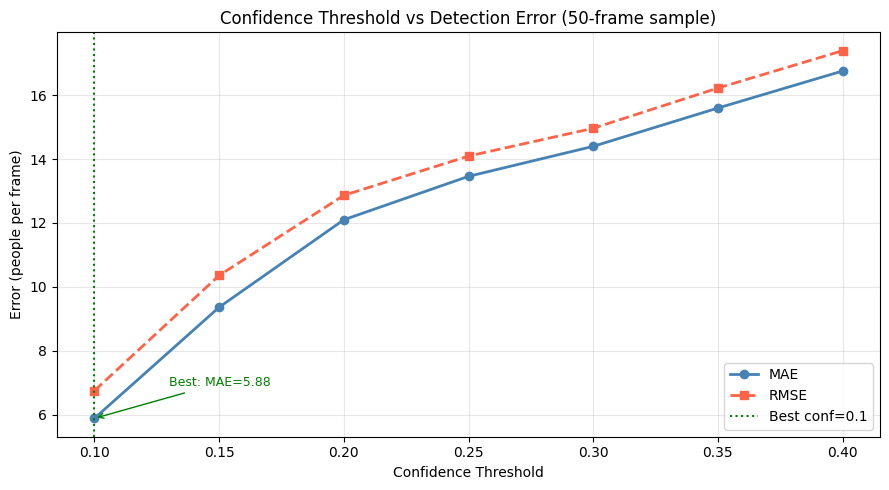

Saved: threshold_vs_error.png


In [ ]:
confs = [r['conf'] for r in threshold_results]
maes  = [r['mae']  for r in threshold_results]
rmses = [r['rmse'] for r in threshold_results]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(confs, maes,  marker='o', color='steelblue', linewidth=2, label='MAE')
ax.plot(confs, rmses, marker='s', color='tomato', linewidth=2, linestyle='--', label='RMSE')
ax.axvline(BEST_CONF, color='green', linestyle=':', linewidth=1.5, label=f'Best conf={BEST_CONF}')
ax.annotate(
    f'Best: MAE={best["mae"]:.2f}',
    xy=(BEST_CONF, best['mae']),
    xytext=(BEST_CONF + 0.03, best['mae'] + 1),
    arrowprops=dict(arrowstyle='->', color='green'),
    fontsize=9, color='green',
)
ax.set_xlabel('Confidence Threshold')
ax.set_ylabel('Error (people per frame)')
ax.set_title('Confidence Threshold vs Detection Error (50-frame sample)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DRIVE_DIR / 'threshold_vs_error.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: threshold_vs_error.png')

In [ ]:
print(f'{"Threshold":<12} {"MAE":<10} {"RMSE":<10} {"Max Error":<12} {"Exact Matches"}')
print('-' * 60)
for r in threshold_results:
    marker = ' <- BEST' if r['conf'] == BEST_CONF else ''
    print(f'{r["conf"]:<12.2f} {r["mae"]:<10.2f} {r["rmse"]:<10.2f} {r["max_error"]:<12d} {r["frames_exact"]}/50{marker}')

Threshold    MAE        RMSE       Max Error    Exact Matches
------------------------------------------------------------
0.10         5.88       6.75       14           2/50 <- BEST
0.15         9.36       10.36      22           1/50
0.20         12.10      12.87      26           0/50
0.25         13.46      14.09      27           0/50
0.30         14.40      14.97      27           0/50
0.35         15.60      16.23      28           0/50
0.40         16.76      17.40      31           0/50


## 8. Full Run — All 2000 Frames

Run YOLOv8n on all 2000 frames using the best threshold.
Results saved to CSV after every frame — safe against session disconnects.
If Colab disconnects, re-run this cell and it will resume from where it stopped.

In [ ]:
OUTPUT_CSV = DRIVE_DIR / 'detection_results.csv'
ALL_FRAMES = list(range(1, 2001))

# Resume from previous run if CSV exists
completed = set()
if OUTPUT_CSV.exists():
    with open(OUTPUT_CSV, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            completed.add(int(row['frame_id']))
    print(f'Resuming: {len(completed)} frames already done.')

remaining = [i for i in ALL_FRAMES if i not in completed]
print(f'Frames to process: {len(remaining)} (conf={BEST_CONF})')

write_header = not OUTPUT_CSV.exists()
start_time = time.time()

with open(OUTPUT_CSV, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['frame_id', 'gt_count', 'detected_count', 'error', 'conf'])
    if write_header:
        writer.writeheader()

    for i, idx in enumerate(remaining):
        detected, _ = detect_persons(model, frame_path(idx), conf=BEST_CONF)
        gt = int(gt_counts[idx - 1])
        error = abs(detected - gt)

        writer.writerow({'frame_id': idx, 'gt_count': gt, 'detected_count': detected, 'error': error, 'conf': BEST_CONF})
        f.flush()  # write immediately — safe against disconnects

        if (i + 1) % 100 == 0 or (i + 1) == len(remaining):
            elapsed = time.time() - start_time
            rate = (i + 1) / elapsed
            eta = (len(remaining) - i - 1) / rate if rate > 0 else 0
            print(f'  [{i + 1:4d}/{len(remaining)}] frame {idx:4d} | {rate:.1f} fps | ETA: {eta/60:.1f} min')

print(f'Done. {len(remaining)} frames in {(time.time() - start_time)/60:.1f} min.')
print(f'Results: {OUTPUT_CSV}')

Frames to process: 2000 (conf=0.1)
  [ 100/2000] frame  100 | 4.3 fps | ETA: 7.4 min
  [ 200/2000] frame  200 | 4.3 fps | ETA: 6.9 min
  [ 300/2000] frame  300 | 4.3 fps | ETA: 6.6 min
  [ 400/2000] frame  400 | 4.4 fps | ETA: 6.1 min
  [ 500/2000] frame  500 | 4.3 fps | ETA: 5.8 min
  [ 600/2000] frame  600 | 4.4 fps | ETA: 5.3 min
  [ 700/2000] frame  700 | 4.4 fps | ETA: 5.0 min
  [ 800/2000] frame  800 | 4.4 fps | ETA: 4.6 min
  [ 900/2000] frame  900 | 4.4 fps | ETA: 4.2 min
  [1000/2000] frame 1000 | 4.4 fps | ETA: 3.8 min
  [1100/2000] frame 1100 | 4.4 fps | ETA: 3.4 min
  [1200/2000] frame 1200 | 4.4 fps | ETA: 3.0 min
  [1300/2000] frame 1300 | 4.4 fps | ETA: 2.7 min
  [1400/2000] frame 1400 | 4.4 fps | ETA: 2.3 min
  [1500/2000] frame 1500 | 4.4 fps | ETA: 1.9 min
  [1600/2000] frame 1600 | 4.4 fps | ETA: 1.5 min
  [1700/2000] frame 1700 | 4.5 fps | ETA: 1.1 min
  [1800/2000] frame 1800 | 4.5 fps | ETA: 0.7 min
  [1900/2000] frame 1900 | 4.5 fps | ETA: 0.4 min
  [2000/2000] f

## 9. Results + Summary

Load the full CSV, compute final metrics, visualize, write accuracy summary.

In [ ]:
full_results = []
with open(OUTPUT_CSV, 'r') as f:
    for row in csv.DictReader(f):
        full_results.append({
            'frame_id': int(row['frame_id']),
            'gt_count': int(row['gt_count']),
            'detected_count': int(row['detected_count']),
            'error': int(row['error']),
        })
full_results.sort(key=lambda x: x['frame_id'])
assert len(full_results) == 2000, f'Expected 2000 rows, got {len(full_results)}'
print(f'Loaded {len(full_results)} results.')

Loaded 2000 results.


In [ ]:
final = compute_metrics(full_results)
gt_all  = np.array([r['gt_count']        for r in full_results])
det_all = np.array([r['detected_count']   for r in full_results])
errors  = np.array([r['error']            for r in full_results])

print('=' * 50)
print('FINAL DETECTION RESULTS — All 2000 Frames')
print('=' * 50)
print(f'  Model:            YOLOv8n (pretrained on COCO, CPU)')
print(f'  Threshold:        {BEST_CONF}')
print(f'  MAE:              {final["mae"]:.2f} people/frame')
print(f'  RMSE:             {final["rmse"]:.2f}')
print(f'  Max error:        {final["max_error"]} people')
print(f'  Exact matches:    {final["frames_exact"]}/2000 ({final["frames_exact"]/20:.1f}%)')
print(f'  GT mean:          {gt_all.mean():.1f}')
print(f'  Detected mean:    {det_all.mean():.1f}')
print('=' * 50)

FINAL DETECTION RESULTS — All 2000 Frames
  Model:            YOLOv8n (pretrained on COCO, CPU)
  Threshold:        0.1
  MAE:              5.71 people/frame
  RMSE:             6.82
  Max error:        21 people
  Exact matches:    87/2000 (4.3%)
  GT mean:          31.2
  Detected mean:    25.9


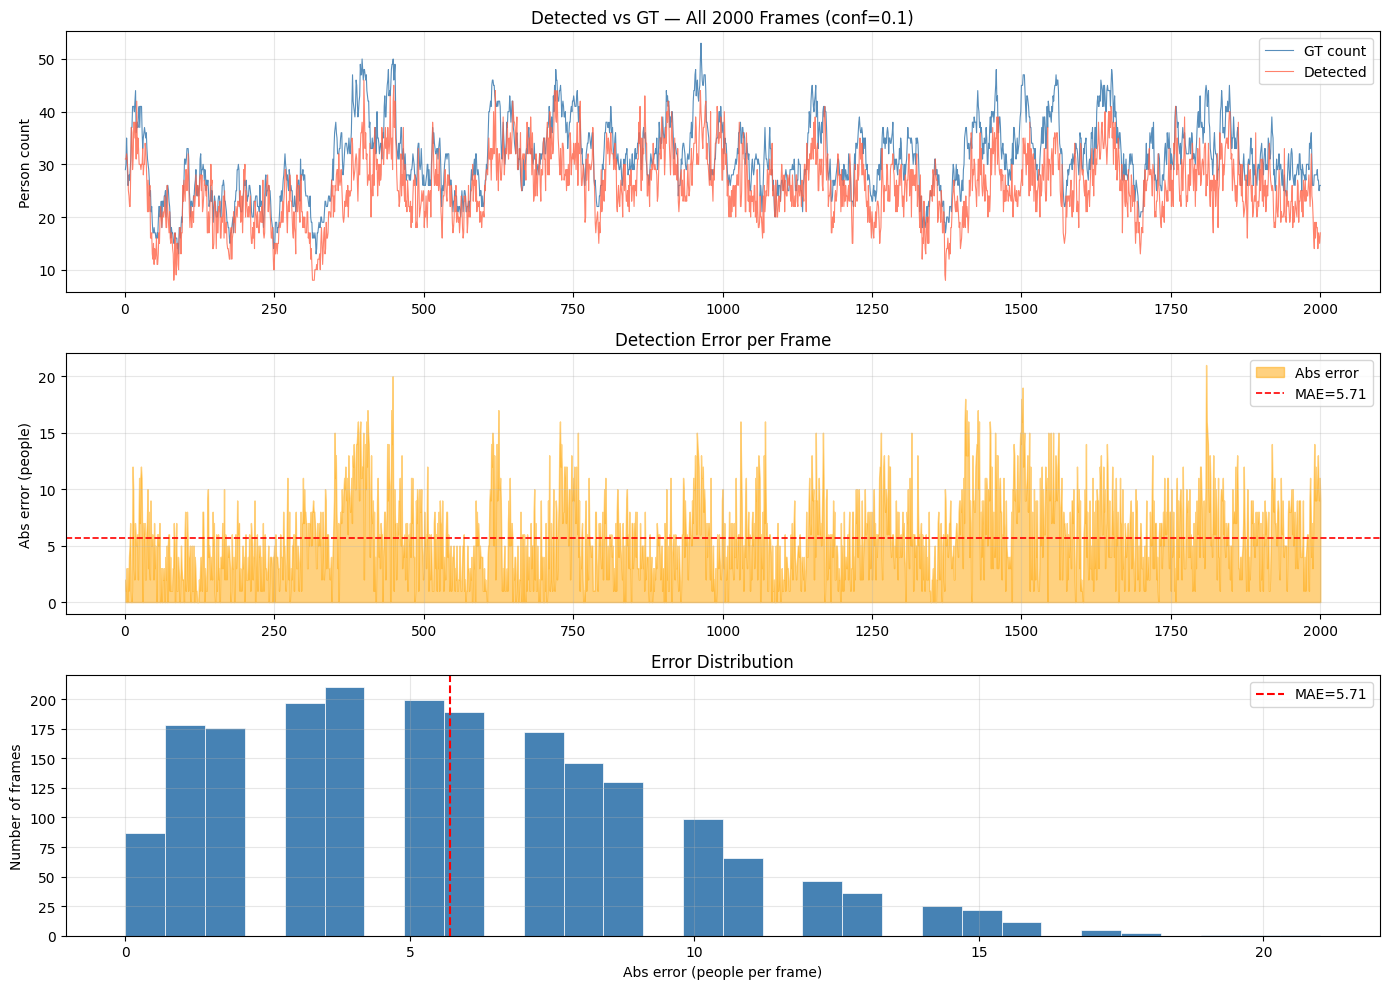

Saved: detection_final_results.png


In [ ]:
frame_ids = [r['frame_id'] for r in full_results]
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(frame_ids, gt_all,  color='steelblue', linewidth=0.8, label='GT count', alpha=0.9)
axes[0].plot(frame_ids, det_all, color='tomato',    linewidth=0.8, label='Detected',  alpha=0.8)
axes[0].set_ylabel('Person count')
axes[0].set_title(f'Detected vs GT — All 2000 Frames (conf={BEST_CONF})')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].fill_between(frame_ids, errors, alpha=0.5, color='orange', label='Abs error')
axes[1].axhline(final['mae'], color='red', linestyle='--', linewidth=1.2, label=f'MAE={final["mae"]:.2f}')
axes[1].set_ylabel('Abs error (people)')
axes[1].set_title('Detection Error per Frame')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].hist(errors, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[2].axvline(final['mae'], color='red', linestyle='--', label=f'MAE={final["mae"]:.2f}')
axes[2].set_xlabel('Abs error (people per frame)')
axes[2].set_ylabel('Number of frames')
axes[2].set_title('Error Distribution')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DRIVE_DIR / 'detection_final_results.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: detection_final_results.png')

In [ ]:
sorted_by_error = sorted(full_results, key=lambda x: x['error'], reverse=True)
worst_10 = sorted_by_error[:10]

print('Top 10 frames with highest error:')
print(f'{"Frame":<10} {"GT":<8} {"Detected":<12} {"Error"}')
print('-' * 40)
for r in worst_10:
    print(f'{r["frame_id"]:<10} {r["gt_count"]:<8} {r["detected_count"]:<12} {r["error"]}')

Top 10 frames with highest error:
Frame      GT       Detected     Error
----------------------------------------
1809       45       24           21
448        49       29           20
1502       45       26           19
1406       36       18           18
1500       45       27           18
406        43       26           17
446        48       31           17
625        42       25           17
1408       37       20           17
1427       44       27           17


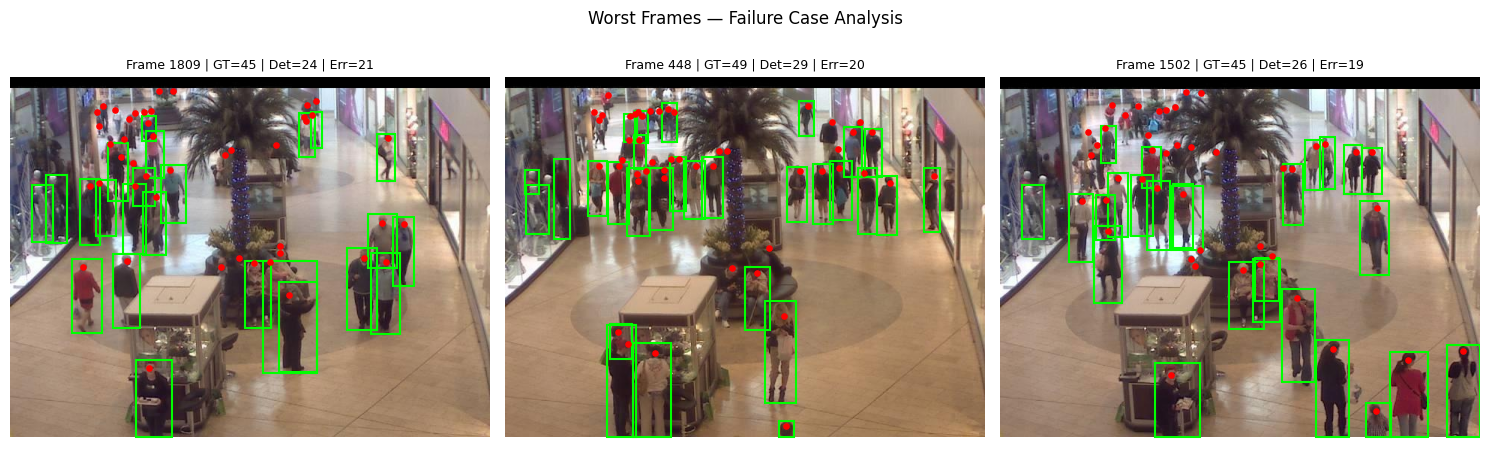

Saved: failure_cases.png


In [ ]:
worst_3 = [r['frame_id'] for r in worst_10[:3]]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, idx in zip(axes, worst_3):
    _, boxes = detect_persons(model, frame_path(idx), conf=BEST_CONF)
    img = cv2.imread(str(frame_path(idx)))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)

    for x1, y1, x2, y2 in boxes:
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1.5, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)

    locs = gt_locations[idx - 1]
    ax.scatter(locs[:, 0], locs[:, 1], c='red', s=14, zorder=5)

    r = next(x for x in full_results if x['frame_id'] == idx)
    ax.set_title(f'Frame {idx} | GT={r["gt_count"]} | Det={r["detected_count"]} | Err={r["error"]}', fontsize=9)
    ax.axis('off')

plt.suptitle('Worst Frames — Failure Case Analysis', fontsize=12)
plt.tight_layout()
plt.savefig(DRIVE_DIR / 'failure_cases.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: failure_cases.png')

In [ ]:
summary = f"""
EPIC 1 — DETECTION ACCURACY SUMMARY
=====================================
Dataset:          Mall Dataset (CUHK), 2000 frames
Model:            YOLOv8n (pretrained on COCO, CPU inference)
Best threshold:   {BEST_CONF}

Metrics (all 2000 frames):
  MAE:            {final['mae']:.2f} people/frame
  RMSE:           {final['rmse']:.2f}
  Max error:      {final['max_error']} people
  Exact matches:  {final['frames_exact']}/2000 ({final['frames_exact']/20:.1f}%)

Known failure cases:
  - Heavy occlusion (people overlapping) causes under-detection
  - Top-down camera angle vs COCO training data (eye-level) reduces confidence
  - Distant/small persons (top of frame) missed at higher thresholds

Why this threshold ({BEST_CONF}):
  Tested 7 thresholds (0.10-0.40) on 50-frame sample.
  {BEST_CONF} gave lowest MAE. See threshold_vs_error.png.

Output files (in Google Drive/shoplens/):
  detection_results.csv         full results per frame
  gt_visualization.png          GT head positions on sample frames
  gt_distribution.png           GT count distribution
  threshold_vs_error.png        threshold tuning chart
  detection_final_results.png   detected vs GT, error over time
  failure_cases.png             3 worst-performing frames
"""

print(summary)
with open(DRIVE_DIR / 'epic1_summary.txt', 'w') as f:
    f.write(summary)
print('Saved: epic1_summary.txt')


EPIC 1 — DETECTION ACCURACY SUMMARY
Dataset:          Mall Dataset (CUHK), 2000 frames
Model:            YOLOv8n (pretrained on COCO, CPU inference)
Best threshold:   0.1

Metrics (all 2000 frames):
  MAE:            5.71 people/frame
  RMSE:           6.82
  Max error:      21 people
  Exact matches:  87/2000 (4.3%)

Known failure cases:
  - Heavy occlusion (people overlapping) causes under-detection
  - Top-down camera angle vs COCO training data (eye-level) reduces confidence
  - Distant/small persons (top of frame) missed at higher thresholds

Why this threshold (0.1):
  Tested 7 thresholds (0.10-0.40) on 50-frame sample.
  0.1 gave lowest MAE. See threshold_vs_error.png.

Output files (in Google Drive/shoplens/):
  detection_results.csv         full results per frame
  gt_visualization.png          GT head positions on sample frames
  gt_distribution.png           GT count distribution
  threshold_vs_error.png        threshold tuning chart
  detection_final_results.png   detected

In [ ]:
# Check if we're over or under detecting
import csv
gt_total = 0
det_total = 0
with open(OUTPUT_CSV) as f:
    for row in csv.DictReader(f):
        gt_total += int(row['gt_count'])
        det_total += int(row['detected_count'])

print(f'Total GT persons:       {gt_total}')
print(f'Total detected persons: {det_total}')
print(f'Over-detecting by: {det_total - gt_total}' if det_total > gt_total else f'Under-detecting by: {gt_total - det_total}')

Total GT persons:       62315
Total detected persons: 51756
Under-detecting by: 10559


In [ ]:
Bias: Under-detection (detected 51,756 vs GT 62,315 total) — model misses ~17% of people due to top-down camera angle mismatch with COCO training data.